In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from toy_disentanglement.task import (
    create_embedding_autoencoder, LatentClassificationDataset, LatentTanhDataset, LatentSinDataset, 
    LatentWaveletDataset, LatentMultiWaveletDataset, LatentGridClassificationDataset
)
from toy_disentanglement.metrics import classification_generalization_accuracy, regression_generalization_r2

In [2]:
import functools

def rep_fn(x, dataset=None):
    with torch.no_grad():
        dataset.latents = x
        dataset._generate_labels()
    return dataset.task_labels

In [3]:
latent_dim = 5

embedding_network = create_embedding_autoencoder(
    input_dim=latent_dim,
    representation_dim=128,
    encoder_hidden_dims=[128,128],
    decoder_hidden_dims=[128,128],
    noise_std=0.0,
    activation="relu",
    train=False,
    num_epochs=4000,
    batch_size=256,
    embedding_type="standard",
    checkpoint_path="data/embedding_nets/embedding_ae_5d_relu_128x2_noiseless.pth"
)

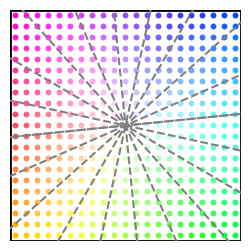

In [4]:
from matplotlib.patches import Rectangle

xx = np.linspace(-4, 4, 21)
yy = np.linspace(-4, 4, 21)
xx, yy = np.meshgrid(xx, yy)
angle_norm = (np.arctan2(yy, xx) + np.pi) / (2 * np.pi)  # Normalize angle to [0, 1]
alpha = np.linalg.norm(np.stack([xx, yy], axis=-1), axis=-1) / np.sqrt(4**2 + 4**2)  # Normalize radius to [0, 1]
alpha = np.clip(alpha, 0, 1)  # Ensure alpha is in [

# Build RGBA colors: hue from angle (HSV), opacity from radius-based alpha
rgba = plt.cm.hsv(angle_norm.ravel())
rgba[:, 3] = alpha.ravel()

fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(xx.ravel(), yy.ravel(), c=rgba, s=18, marker='o', linewidths=0)

# Black box around the grid bounds
ax.add_patch(Rectangle((-4.2, -4.2), 8.4, 8.4, fill=False, edgecolor="black", linewidth=2))

num_lines = 10
for i in range(num_lines + 1):
    # random angle
    angle = np.pi * i / num_lines + 0.1
    cos = np.cos(angle)
    sin = np.sin(angle)
    # line endpoints
    x1, y1 = -8 * cos, -8 * sin
    x2, y2 = 8 * cos, 8 * sin
    ax.plot([x1, x2], [y1, y2], "--", color="gray")

# Remove axis lines/ticks and keep square aspect
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-4.2, 4.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()
plt.close()

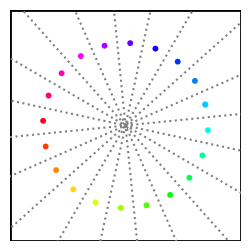

In [15]:
from matplotlib.patches import Rectangle

theta = np.linspace(0, 2 * np.pi, 21) + np.pi / 20 + 0.1
r = 3
x = r * np.cos(theta)
y = r * np.sin(theta)
angle_norm = (np.arctan2(y, x) + np.pi) / (2 * np.pi)  # Normalize angle to [0, 1]
alpha = np.linalg.norm(np.stack([x, y], axis=-1), axis=-1) / r  # Normalize radius to [0, 1]
alpha = np.clip(alpha, 0, 1)  # Ensure alpha is in [0, 1]

# Build RGBA colors: hue from angle (HSV), opacity from radius-based alpha
rgba = plt.cm.hsv(angle_norm.ravel())
rgba[:, 3] = alpha.ravel()

fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(x.ravel(), y.ravel(), c=rgba, s=18, marker='o', linewidths=0)

# Black box around the grid bounds
ax.add_patch(Rectangle((-4.2, -4.2), 8.4, 8.4, fill=False, edgecolor="black", linewidth=2))

num_lines = 10
for i in range(num_lines):
    # random angle
    angle = np.pi * i / num_lines + 0.1
    cos = np.cos(angle)
    sin = np.sin(angle)
    # line endpoints
    x1, y1 = -8 * cos, -8 * sin
    x2, y2 = 8 * cos, 8 * sin
    ax.plot([x1, x2], [y1, y2], ":", color="gray")

# Remove axis lines/ticks and keep square aspect
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-4.2, 4.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()
plt.close()

In [12]:
dataset = LatentClassificationDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=3, 
    embedding_fn=embedding_network.encoder, 
    bias=False, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
)

In [46]:
x.shape

torch.Size([1000, 3])

Text(0.5, 1.0, 'zero-threshold classification')

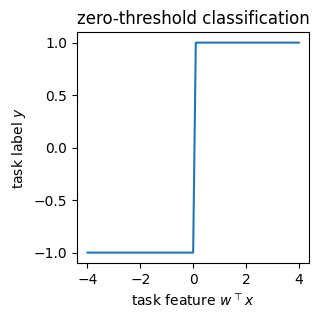

In [ ]:
fig = plt.figure(figsize=(3, 3))
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = torch.sign(x)
idx = torch.argsort(x[:, 0])
plt.plot(x[idx, 0], y[idx, 0])
plt.xlabel(r'task feature $w^{\top} x$')
plt.ylabel(r'task label $y$')

Text(0.5, 1.0, 'shifted classification')

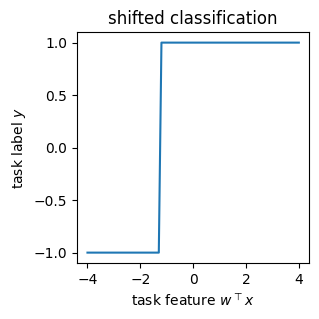

In [39]:
fig = plt.figure(figsize=(3, 3))
with torch.no_grad():
    x = torch.linspace(-4, 4, 81)
    y = torch.sign(x + 1.2)
plt.plot(x, y)
plt.xlabel(r'task feature $w^{\top} x$')
plt.ylabel(r'task label $y$')
plt.title('shifted classification')

Text(0.5, 1.0, 'tanh')

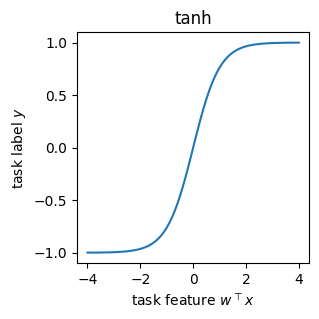

In [40]:
fig = plt.figure(figsize=(3, 3))
with torch.no_grad():
    x = torch.linspace(-4, 4, 81)
    y = torch.tanh(x)
plt.plot(x, y)
plt.xlabel(r'task feature $w^{\top} x$')
plt.ylabel(r'task label $y$')
plt.title('tanh')

In [6]:
train_acc, test_acc = classification_generalization_accuracy(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_acc.mean(), test_acc.mean())

train_r2, test_r2 = regression_generalization_r2(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_r2.mean(), test_r2.mean())

0.7325781365102583 0.7003824985036566
0.3691664066944213 0.2700741787901817


In [7]:
dataset = LatentTanhDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=5, 
    embedding_fn=embedding_network.encoder, 
    bias=False, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
)

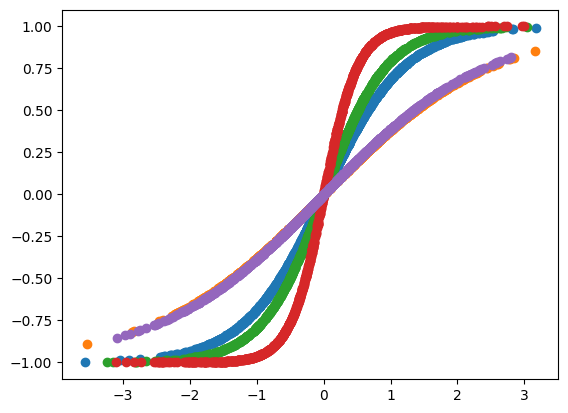

In [8]:
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = dataset.task_labels
for i in range(x.shape[1]):
    plt.scatter(x[:, i], y[:, i])

In [9]:
train_acc, test_acc = classification_generalization_accuracy(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_acc.mean(), test_acc.mean())

train_r2, test_r2 = regression_generalization_r2(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_r2.mean(), test_r2.mean())

0.8415201691104763 0.7812130588828937
0.7383070889266685 0.5604019595235744


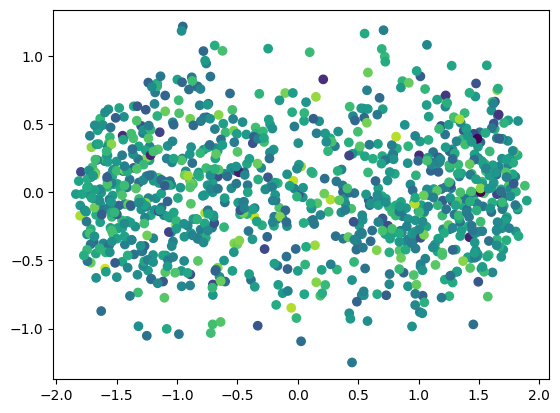

In [10]:
pca = PCA(n_components=2)
y_pca = pca.fit_transform(y)
plt.scatter(y_pca[:, 0], y_pca[:, 1], c=dataset.latents[:, 0])

In [11]:
dataset = LatentSinDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=5, 
    embedding_fn=embedding_network.encoder, 
    bias=True, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
)

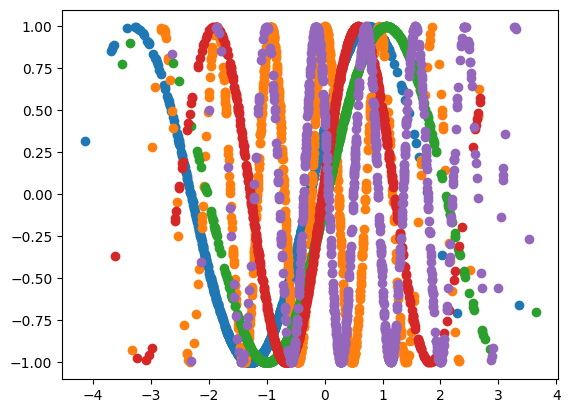

In [12]:
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = dataset.task_labels
for i in range(x.shape[1]):
    plt.scatter(x[:, i], y[:, i])

In [13]:
train_acc, test_acc = classification_generalization_accuracy(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_acc.mean(), test_acc.mean())

train_r2, test_r2 = regression_generalization_r2(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_r2.mean(), test_r2.mean())

0.648176110158465 0.608680298368729
0.13557059412314346 0.056228301495585636


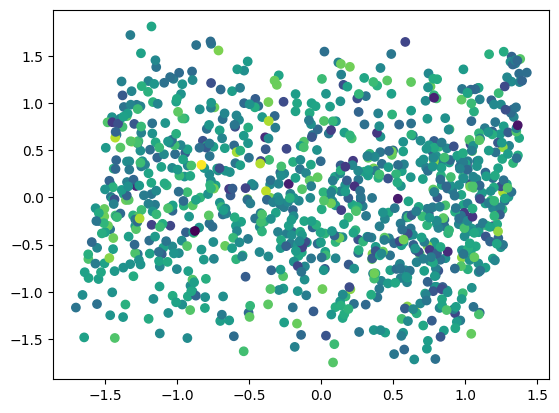

In [14]:
pca = PCA(n_components=2)
y_pca = pca.fit_transform(y)
plt.scatter(y_pca[:, 0], y_pca[:, 1], c=dataset.latents[:, 0])

In [41]:
dataset = LatentWaveletDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=5, 
    embedding_fn=embedding_network.encoder, 
    bias=True, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
    sin_scale=0.5,
)

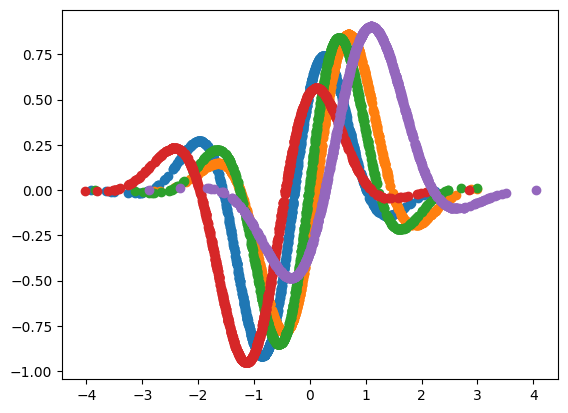

In [42]:
with torch.no_grad():
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = dataset.task_labels
for i in range(x.shape[1]):
    plt.scatter(x[:, i], y[:, i])

In [45]:
dataset.latents.shape

torch.Size([1000, 5])

Text(0.5, 1.0, 'wavelet task')

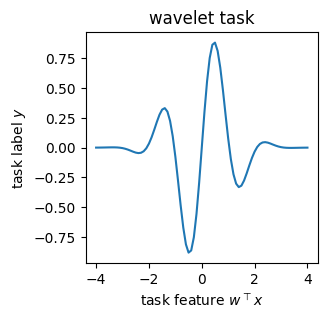

In [53]:
fig = plt.figure(figsize=(3, 3))
with torch.no_grad():
    dataset.latents = dataset.task_weights[:, 0].unsqueeze(0) * (torch.linspace(-4, 4, 81).unsqueeze(1) - dataset.task_bias[0])
    dataset._generate_labels()
    x = dataset.latents @ dataset.task_weights + dataset.task_bias
    y = dataset.task_labels
idx = torch.argsort(x[:, 0])
plt.plot(x[idx, 0], y[idx, 0])
plt.xlabel(r'task feature $w^{\top} x$')
plt.ylabel(r'task label $y$')
plt.title('wavelet task')

In [26]:
train_acc, test_acc = classification_generalization_accuracy(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_acc.mean(), test_acc.mean())

train_r2, test_r2 = regression_generalization_r2(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_r2.mean(), test_r2.mean())

0.7043912794939977 0.6581645751365884
0.2718178508676321 0.12469226992473434


In [4]:
dataset = LatentMultiWaveletDataset(
    latent_dim=latent_dim, 
    num_samples=1000, 
    num_tasks=10, 
    embedding_fn=embedding_network.encoder, 
    bias=True, 
    correlation=0.0, 
    sparsity=0.0, 
    task_correlation=0.0,
    sin_scale=0.5,
    task_dim=2,
)

In [10]:
(dataset.task_weights[:, 0, 0].unsqueeze(0) * (torch.linspace(-4, 4, 81).unsqueeze(1) - dataset.task_bias[0, 0])).shape

torch.Size([81, 5])

Text(0.5, 1.0, '2d-wavelet task')

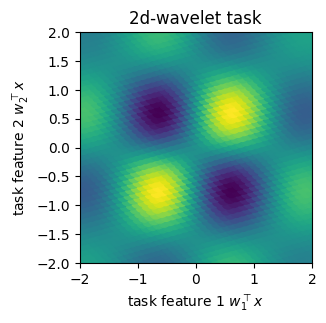

In [22]:
fig = plt.figure(figsize=(3, 3))
with torch.no_grad():
    latents_dim1 = dataset.task_weights[:, 0, 0].unsqueeze(0) * (torch.linspace(-4, 4, 81).unsqueeze(1) - dataset.task_bias[0, 0])
    latents_dim2 = dataset.task_weights[:, 1, 0].unsqueeze(0) * (torch.linspace(-4, 4, 81).unsqueeze(1) - dataset.task_bias[1, 0])
    latents = (latents_dim1.unsqueeze(0) + latents_dim2.unsqueeze(1)).reshape(-1, latent_dim)
    dataset.latents = latents
    dataset._generate_labels()
    task_proj = torch.einsum('ni,ijd->njd', dataset.latents, dataset.task_weights) + dataset.task_bias
    y = dataset.task_labels
task_idx = 0
plt.scatter(task_proj[:, 0, task_idx], task_proj[:, 1, task_idx], c=y[:, task_idx], s=80)
plt.xlim(-2.0, 2.0)
plt.ylim(-2.0, 2.0)
plt.xlabel(r'task feature 1 $w_1^{\top} x$')
plt.ylabel(r'task feature 2 $w_2^{\top} x$')
plt.title('2d-wavelet task')

In [20]:
train_acc, test_acc = classification_generalization_accuracy(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_acc.mean(), test_acc.mean())

train_r2, test_r2 = regression_generalization_r2(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_r2.mean(), test_r2.mean())

0.6698899677724057 0.5210247043158323
0.18032746550669138 -0.11208127483811844


In [21]:
dataset = LatentGridClassificationDataset(
    latent_dim=5, 
    num_samples=1000, 
    num_tasks=10, 
    embedding_fn=embedding_network.encoder, 
    divisions=3,
)

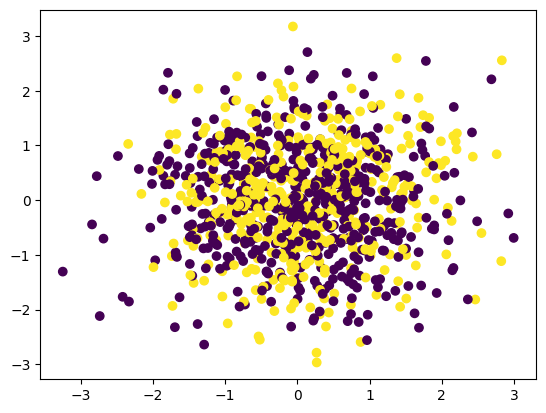

In [22]:
with torch.no_grad():
    z = dataset.latents
    y = dataset.task_labels
task_idx = 0
plt.scatter(z[:, 0], z[:, 1], c=y[:, task_idx])

In [23]:
train_acc, test_acc = classification_generalization_accuracy(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_acc.mean(), test_acc.mean())

train_r2, test_r2 = regression_generalization_r2(
    rep_fn=functools.partial(rep_fn, dataset=dataset),
    data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
    embed_fn=torch.nn.Identity(),
)
print(train_r2.mean(), test_r2.mean())

0.6059914462693914 0.5147899389556246
0.07204075184316777 -0.04735548367432338


In [25]:
def plot_metrics(metrics, task_name="Classification"):
    plt.figure(figsize=(5.2, 3.1))
    plt.subplot(1, 2, 1)

    # plt.plot([m['num_tasks'] for m in metrics], [m['train_acc'] for m in metrics], label='train', marker="o", color="#1f77b4")
    # plt.plot([m['num_tasks'] for m in metrics], [m['test_acc'] for m in metrics], label='test', marker="o", color="#d62728")
    plt.plot([m['num_tasks'] for m in metrics], [m['test_acc'] for m in metrics], label='test', marker="o", color="#1f77b4")
    plt.xlabel('# tasks')
    plt.ylabel('classifier generalization')
    plt.xscale('log')
    plt.xticks([2, 5, 10, 20, 50], [2, 5, 10, 20, 50])
    plt.ylim(0.5, 1.0)
    # plt.title('Generalization Accuracy vs Number of Tasks')
    # plt.legend()

    plt.subplot(1, 2, 2)
    # plt.plot([m['num_tasks'] for m in metrics], [max(m['train_r2'], 0) for m in metrics], label='train', marker="o", color="#1f77b4")
    # plt.plot([m['num_tasks'] for m in metrics], [max(m['test_r2'], 0) for m in metrics], label='test', marker="o", color="#d62728")
    plt.plot([m['num_tasks'] for m in metrics], [max(m['test_r2'], 0) for m in metrics], label='test', marker="o", color="#1f77b4")
    # plt.xscale('log')
    plt.xlabel('# tasks')
    plt.ylabel('regression generalization')
    plt.xscale('log')
    plt.xticks([2, 5, 10, 20, 50], [2, 5, 10, 20, 50])
    plt.ylim(0.0, 1.0)
    # plt.title('Generalization R2 vs Number of Tasks')
    # plt.legend()

    plt.suptitle(f'Abstractness of {task_name} task outputs')
    plt.tight_layout()
    plt.show()

In [26]:
metrics = []

for num_tasks in [2, 4, 6, 8, 10, 15, 20, 30, 50]:
    dataset = LatentClassificationDataset(
        latent_dim=latent_dim, 
        num_samples=1000, 
        num_tasks=num_tasks, 
        embedding_fn=embedding_network.encoder, 
        bias=False, 
        correlation=0.0, 
        sparsity=0.0, 
        task_correlation=0.0,
    )
    train_acc, test_acc = classification_generalization_accuracy(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    train_r2, test_r2 = regression_generalization_r2(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    metrics.append(dict(
        num_tasks=num_tasks,
        train_acc=train_acc.mean().item(),
        test_acc=test_acc.mean().item(),
        train_r2=train_r2.mean().item(),
        test_r2=test_r2.mean().item(),
    ))

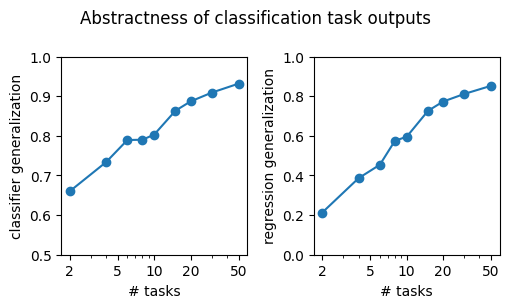

In [27]:
plot_metrics(metrics, task_name="classification")

In [28]:
metrics = []

for num_tasks in [2, 4, 6, 8, 10, 15, 20, 30, 50]:
    dataset = LatentGridClassificationDataset(
        latent_dim=latent_dim, 
        num_samples=1000, 
        num_tasks=num_tasks, 
        embedding_fn=embedding_network.encoder, 
        correlation=0.0, 
        divisions=3,
    )
    train_acc, test_acc = classification_generalization_accuracy(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    train_r2, test_r2 = regression_generalization_r2(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    metrics.append(dict(
        num_tasks=num_tasks,
        train_acc=train_acc.mean().item(),
        test_acc=test_acc.mean().item(),
        train_r2=train_r2.mean().item(),
        test_r2=test_r2.mean().item(),
    ))

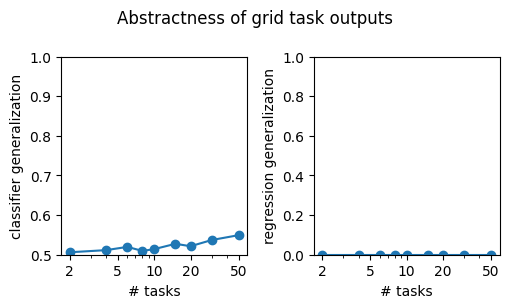

In [29]:
plot_metrics(metrics, task_name="grid")

In [33]:
metrics = []

for num_tasks in [2, 4, 6, 8, 10, 15, 20, 30, 50]:
    dataset = LatentClassificationDataset(
        latent_dim=latent_dim, 
        num_samples=1000, 
        num_tasks=num_tasks, 
        embedding_fn=embedding_network.encoder, 
        correlation=0.0, 
        bias=True,
    )
    train_acc, test_acc = classification_generalization_accuracy(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    train_r2, test_r2 = regression_generalization_r2(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    metrics.append(dict(
        num_tasks=num_tasks,
        train_acc=train_acc.mean().item(),
        test_acc=test_acc.mean().item(),
        train_r2=train_r2.mean().item(),
        test_r2=test_r2.mean().item(),
    ))

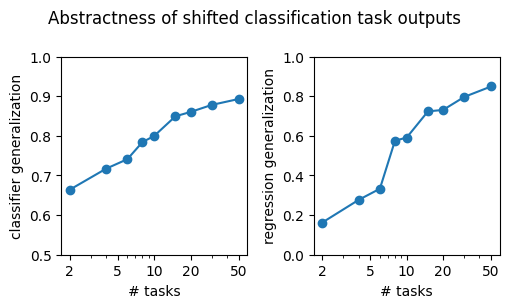

In [34]:
plot_metrics(metrics, task_name="shifted classification")

In [30]:
metrics = []

for num_tasks in [2, 4, 6, 8, 10, 15, 20, 30, 50]:
    dataset = LatentTanhDataset(
        latent_dim=latent_dim, 
        num_samples=1000, 
        num_tasks=num_tasks, 
        embedding_fn=embedding_network.encoder, 
        correlation=0.0, 
        bias=False,
    )
    train_acc, test_acc = classification_generalization_accuracy(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    train_r2, test_r2 = regression_generalization_r2(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    metrics.append(dict(
        num_tasks=num_tasks,
        train_acc=train_acc.mean().item(),
        test_acc=test_acc.mean().item(),
        train_r2=train_r2.mean().item(),
        test_r2=test_r2.mean().item(),
    ))

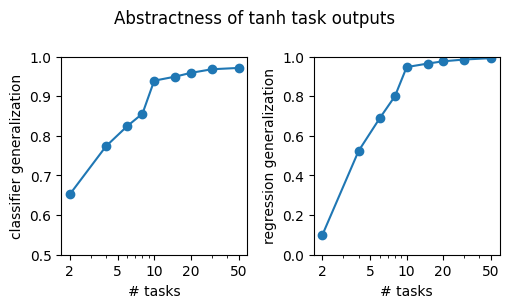

In [ ]:
plot_metrics(metrics, task_name="tanh")

In [50]:
metrics = []

for num_tasks in [2, 4, 6, 8, 10, 15, 20, 30, 50]:
    dataset = LatentWaveletDataset(
        latent_dim=latent_dim, 
        num_samples=1000, 
        num_tasks=num_tasks, 
        embedding_fn=embedding_network.encoder, 
        correlation=0.0, 
        bias=False,
        sin_scale=1.0,
    )
    train_acc, test_acc = classification_generalization_accuracy(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    train_r2, test_r2 = regression_generalization_r2(
        rep_fn=functools.partial(rep_fn, dataset=dataset),
        data_dist=torch.distributions.normal.Normal(torch.zeros(latent_dim), torch.ones(latent_dim)),
        embed_fn=torch.nn.Identity(),
    )
    metrics.append(dict(
        num_tasks=num_tasks,
        train_acc=train_acc.mean().item(),
        test_acc=test_acc.mean().item(),
        train_r2=train_r2.mean().item(),
        test_r2=test_r2.mean().item(),
    ))

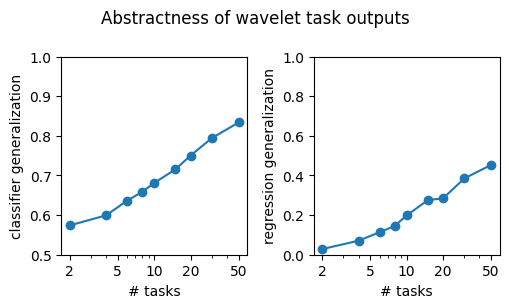

In [52]:
plot_metrics(metrics, task_name="wavelet")